# CNN
CNN(Convolutional Neural Network) is a class of deep neural networks, designed to process data with a grid-like topology, such as images. CNNs are particularly effective for image recognition and classification tasks due to their ability to capture spatial hierarchies in data.

Humans see -> shapes, edges, textures -> objects\
CNN sees -> pixels -> patterns -> shapes, edges, textures -> objects

### How CNN Thinks
A CNN learns in a hierarchical manner. It starts by learning low-level features such as edges and textures in the initial layers. As the data passes through deeper layers, the network learns more complex features, such as shapes and objects. This hierarchical learning allows CNNs to effectively recognize and classify images.
1. Edges: The first layers of a CNN typically learn to detect edges in the input images. This is done by applying convolutional filters that respond to specific patterns of pixel intensity, such as vertical or horizontal lines.
2. Textures: As the data moves through the network, subsequent layers learn to recognize textures by combining the edge information from previous layers. This allows the network to identify patterns that are characteristic of different materials or surfaces.
3. Shapes/Parts: Deeper layers of the CNN learn to recognize shapes by combining the edge and texture information. This enables the network to identify more complex structures, such as circles, squares, or other geometric forms.
4. Objects: Finally, the deepest layers of the CNN learn to recognize entire objects by combining the shapes and parts identified in previous layers. This allows the network to classify images based on the objects they contain.

### Core Ideas of CNN
CNN uses filters (also known as kernels) to scan through the input data and extract features. Filter is a small matrix of weights that slides over the input data to detect specific features. The core ideas of CNN include:
1. Convolution: This is the process of applying a filter to the input data to produce a feature map. The filter is moved across the input data, and at each position, a dot product is computed between the filter and the input data. This allows the network to detect specific features in the input.
2. Pooling: This is a downsampling operation that reduces the spatial dimensions of the feature maps. Pooling helps to reduce the computational complexity of the network and also makes it more robust to variations in the input data. Common pooling methods include max pooling and average pooling.
3. Activation Functions: After convolution and pooling, activation functions are applied to introduce non-linearity into the network. This allows the CNN to learn more complex patterns in the data. Common activation functions include ReLU (Rectified Linear Unit) and sigmoid.
4. Fully Connected Layers: After the convolutional and pooling layers, fully connected layers are used to make the final classification. These layers take the high-level features extracted by the convolutional layers and use them to classify the input data into different categories.

Example: Lets say we have an matrix of $5 \times 5$ pixels of an image and we want to apply a $3 \times 3$ filter to it. The filter will slide over the input matrix, and at each position, it will compute a dot product between the filter and the corresponding region of the input matrix. This will produce a feature map that highlights specific features in the input image, such as edges or textures.
```math
Input Matrix:
\begin{bmatrix}
1 & 2 & 3 & 0 & 1 \\
2 & 3 & 4 & 1 & 2 \\
3 & 4 & 5 & 2 & 3 \\
0 & 1 & 2 & 3 & 4 \\
1 & 2 & 3 & 4 & 5
\end{bmatrix}
```
```math
Filter:
\begin{bmatrix}
1 & 0 & -1 \\
1 & 0 & -1 \\
1 & 0 & -1
\end{bmatrix}
```

The first position of the filter will be applied to the top-left corner of the input matrix, and the dot product will be computed as follows:

$$=\begin{bmatrix}
1 & 2 & 3 \\
2 & 3 & 4 \\
3 & 4 & 5
\end{bmatrix} \cdot \begin{bmatrix}
1 & 0 & -1 \\
1 & 0 & -1 \\
1 & 0 & -1
\end{bmatrix}$$

$$=\begin{bmatrix}
(1 \times 1) + (2 \times 0) + (3 \times -1) + (2 \times 1) + (3 \times 0) + (4 \times -1) + (3 \times 1) + (4 \times 0) + (5 \times -1)
\end{bmatrix}$$

$$=\begin{bmatrix}
(1) + (0) + (-3) + (2) + (0) + (-4) + (3) + (0) + (-5)
\end{bmatrix}$$

$$=\begin{bmatrix}
-7
\end{bmatrix}$$

This process will be repeated as the filter slides across the input matrix, producing a feature map that highlights specific features in the input image. The final feature map matrix will be:
```math
Feature Map:
\begin{bmatrix}
-7 & -4 & -1 \\
-4 & -1 & 2 \\
-1 & 2 & 5
\end{bmatrix}
```
If the input matrix is $n \times n$ and the filter is $m \times m$, the resulting feature map will be of size $(n-m+1) \times (n-m+1)$. In this example, the input matrix is $5 \times 5$ and the filter is $3 \times 3$, so the resulting feature map is $3 \times 3$.\
This feature map can then be further processed by pooling layers and fully connected layers to make the final classification of the input image.

#### Filters(Kernels)
Filters, also known as kernels, are small matrices of weights that are used in convolutional layers to detect specific features in the input data. Each filter is designed to respond to a particular pattern in the input, such as edges, textures, or shapes. The filters are learned during the training process of the CNN, and they play a crucial role in feature extraction.
For example, a filter designed to detect vertical edges might have weights that respond strongly to changes in pixel intensity in the vertical direction. When this filter is applied to an input image, it will produce a feature map that highlights the vertical edges present in the image. Similarly, a filter designed to detect horizontal edges would respond to changes in pixel intensity in the horizontal direction, producing a feature map that highlights horizontal edges.

### Convolution on RGB or Volume
When applying convolution to RGB images, the input data is typically represented as a 3D tensor with dimensions corresponding to the height, width, and number of channels (in this case, 3 for RGB). The convolution operation is applied separately to each channel, and the resulting feature maps are then combined to produce the final output.

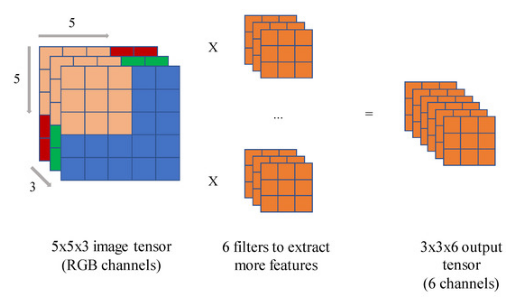

In [1]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

image = Image.open('cnn_on_rgb.jpg')
plt.imshow(image)
plt.axis('off')
plt.show()

In [ ]:
image_array = np.array(image)
print(image_array.shape)    # (height, width, channels)

(319, 550, 3)


In [4]:
image_array

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

(np.float64(-0.5), np.float64(549.5), np.float64(318.5), np.float64(-0.5))

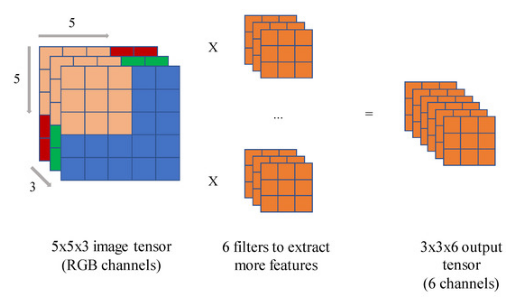

In [5]:
array_to_image = Image.fromarray(image_array)
plt.imshow(array_to_image)
plt.axis('off')